Write a program to Generate a synthetic dataset representing electronic components based on their
voltage and current characteristics using Kmeans Clustering.
The dataset contains two clusters based on Voltage and Current.
The dataset contains two clusters based on Voltage and Current.
 Cluster 0 corresponds to low voltage and current values.
 Cluster 1 corresponds to higher voltage and current values.

Voltage Current Cluste
r

4.81994
1 0.87293 0
5.24978
6
0.91835
8 0

4.77115
1
0.95877
5 0

4.60271
2
1.08778
8 0

4.81491
9
0.87773
9 0

12.3828
1
2.25714
1 1

12.3640
6
2.38365
7 1

11.2295

8 1.89107 1

12.1797

5 1.82507 1

12.0638

2.29575 1

In [18]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

### Generating a Synthetic Dataset

I will create a synthetic dataset with two clusters based on the voltage and current characteristics. The data will be generated using normal distributions, with different means and standard deviations for each cluster to represent 'low' and 'high' values.

*   **Cluster 0 (Low Voltage & Current):** Mean Voltage ~5V, Mean Current ~1A
*   **Cluster 1 (Higher Voltage & Current):** Mean Voltage ~12V, Mean Current ~2A

In [19]:
# Set random seed for reproducibility
np.random.seed(42)

# Number of samples for each cluster
n_samples = 100

# Cluster 0: Low Voltage and Current
voltage_0 = np.random.normal(loc=5.0, scale=0.5, size=n_samples) # Mean 5.0V, Std Dev 0.5V
current_0 = np.random.normal(loc=1.0, scale=0.2, size=n_samples) # Mean 1.0A, Std Dev 0.2A
cluster_0_data = pd.DataFrame({'Voltage': voltage_0, 'Current': current_0, 'True_Cluster': 0})

# Cluster 1: Higher Voltage and Current
voltage_1 = np.random.normal(loc=12.0, scale=0.8, size=n_samples) # Mean 12.0V, Std Dev 0.8V
current_1 = np.random.normal(loc=2.0, scale=0.3, size=n_samples) # Mean 2.0A, Std Dev 0.3A
cluster_1_data = pd.DataFrame({'Voltage': voltage_1, 'Current': current_1, 'True_Cluster': 1})

# Combine the dataframes
synthetic_data = pd.concat([cluster_0_data, cluster_1_data], ignore_index=True)

display(synthetic_data.head())

,Voltage,Current,True_Cluster
0,5.248357,0.716926,0
1,4.930868,0.915871,0
2,5.323844,0.931457,0
3,5.761515,0.839545,0
4,4.882923,0.967743,0


### Applying K-Means Clustering

Now, I will apply K-Means clustering to the synthetic dataset. I will specify `n_clusters=2` as per the problem description and use the 'Voltage' and 'Current' columns as features for clustering.

In [20]:
# Prepare data for clustering
X = synthetic_data[['Voltage', 'Current']]

# Initialize and fit KMeans model
# Using n_init='auto' for sklearn versions >= 1.2
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
synthetic_data['Predicted_Cluster'] = kmeans.fit_predict(X)

display(synthetic_data.head())

,Voltage,Current,True_Cluster,Predicted_Cluster
0,5.248357,0.716926,0,0
1,4.930868,0.915871,0,0
2,5.323844,0.931457,0,0
3,5.761515,0.839545,0,0
4,4.882923,0.967743,0,0


### Visualizing the Clusters

To confirm that K-Means has successfully identified the two distinct clusters, I will visualize the data points colored by their predicted cluster.

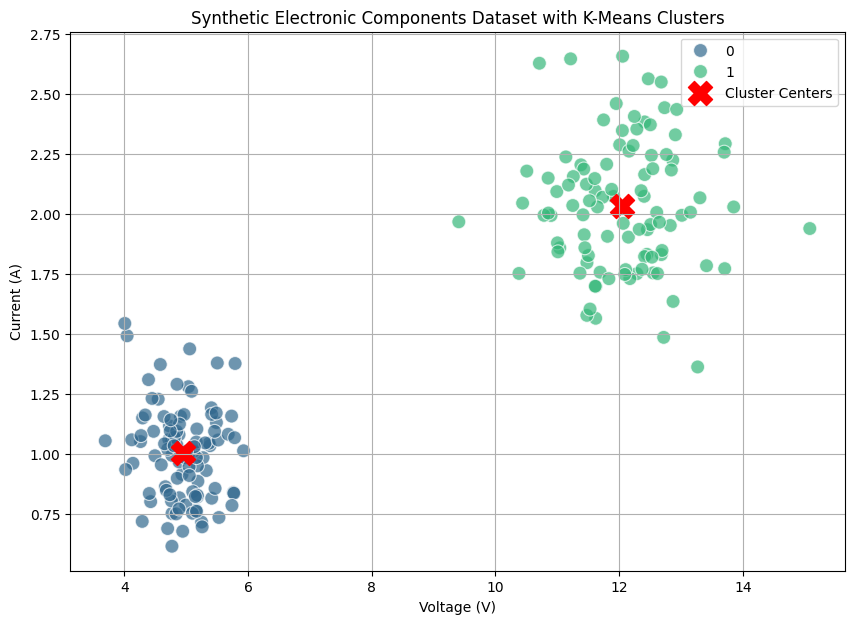

Cluster 0 corresponds to low voltage/current, Cluster 1 to higher voltage/current.


In [21]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=synthetic_data, x='Voltage', y='Current', hue='Predicted_Cluster', palette='viridis', s=100, alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='X', label='Cluster Centers')
plt.title('Synthetic Electronic Components Dataset with K-Means Clusters')
plt.xlabel('Voltage (V)')
plt.ylabel('Current (A)')
plt.legend()
plt.grid(True)
plt.show()

# Additionally, let's compare the predicted clusters with the true clusters if they are perfectly aligned based on the mean values
# K-means might assign 0 to what we called 1 and vice versa, so we check the means.
cluster_means = synthetic_data.groupby('Predicted_Cluster')[['Voltage', 'Current']].mean()

if cluster_means.loc[0, 'Voltage'] < cluster_means.loc[1, 'Voltage']:
    print("Cluster 0 corresponds to low voltage/current, Cluster 1 to higher voltage/current.")
else:
    print("Cluster 0 corresponds to higher voltage/current, Cluster 1 to low voltage/current.")
    print("Note: K-Means assigns cluster labels arbitrarily, so 0 and 1 might be swapped.")